In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, r2_score, mean_squared_error
df = pd.read_csv(r"C:\Users\Pratyasha\Downloads\archive (4)\winequality-red.csv")
df.info

<bound method DataFrame.info of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067

In [33]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [34]:
df = df.drop_duplicates()

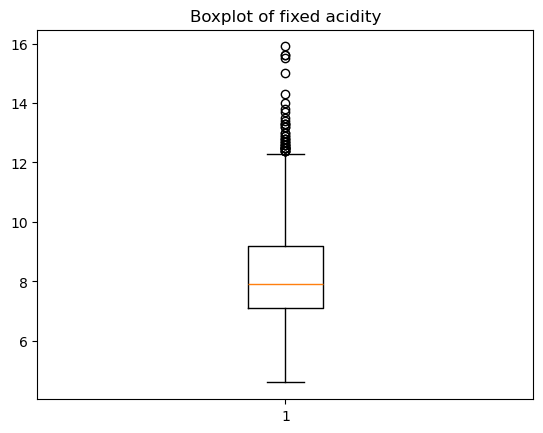

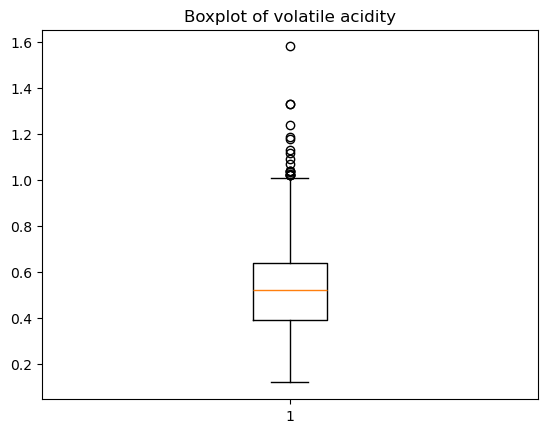

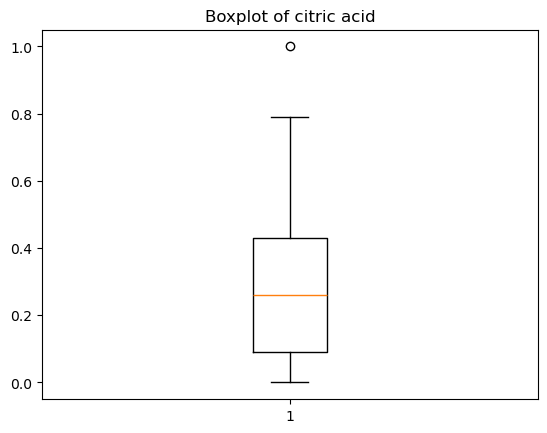

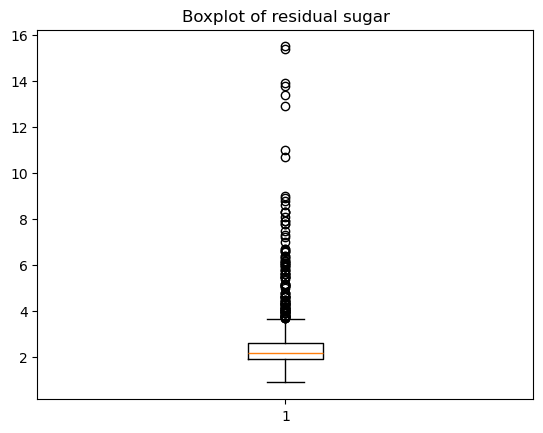

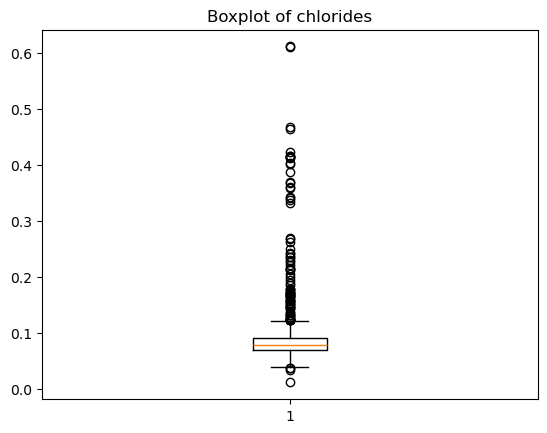

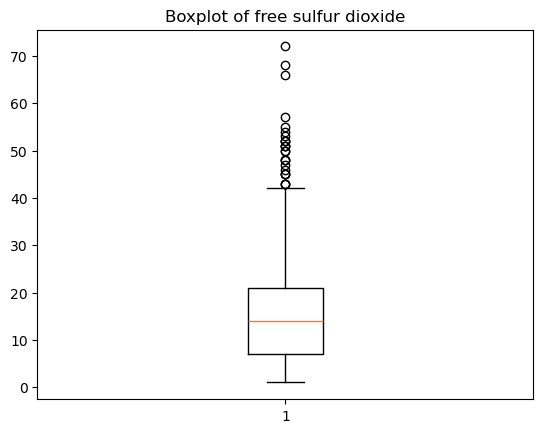

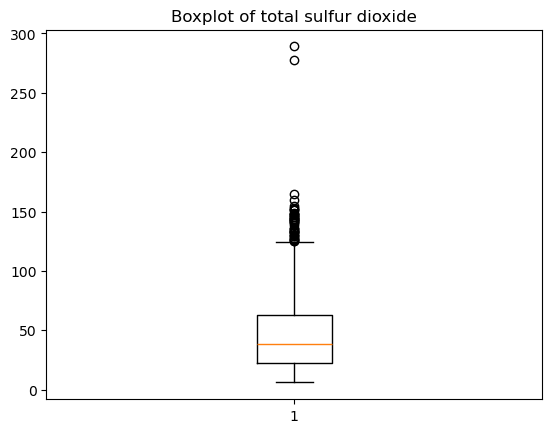

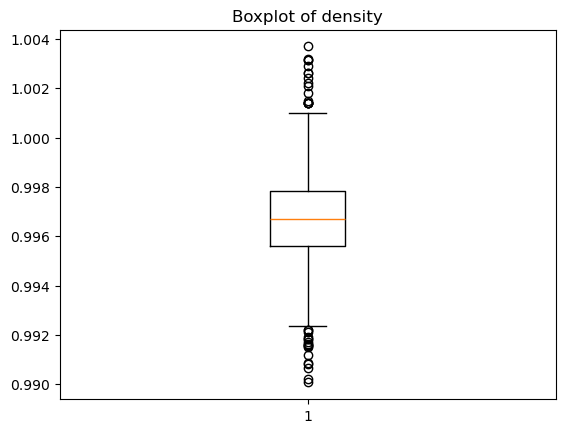

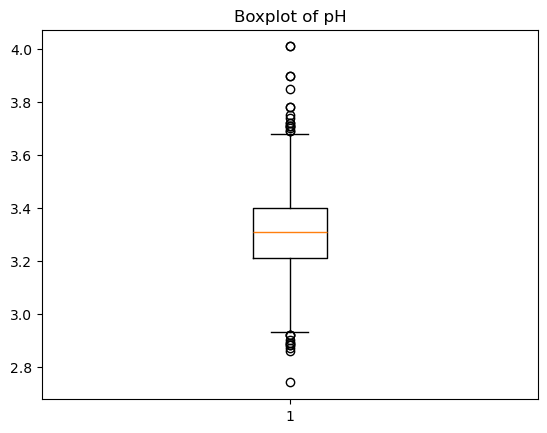

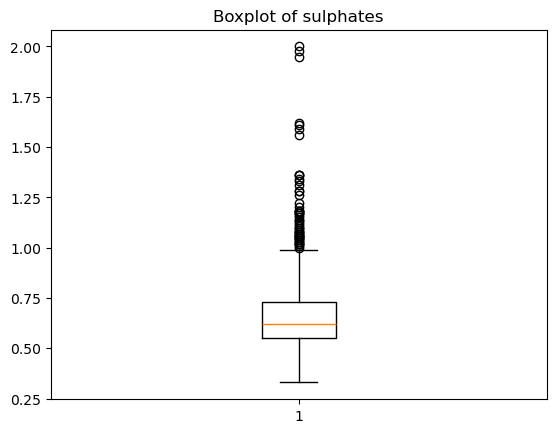

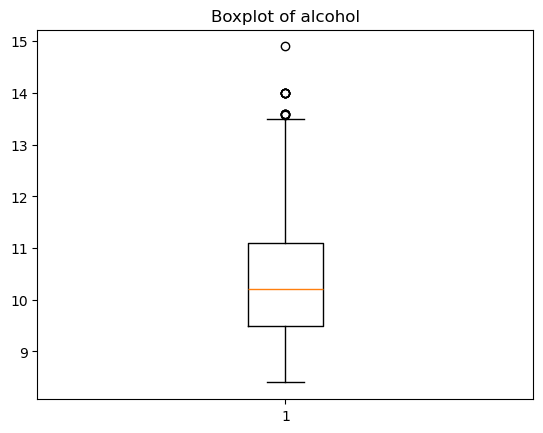

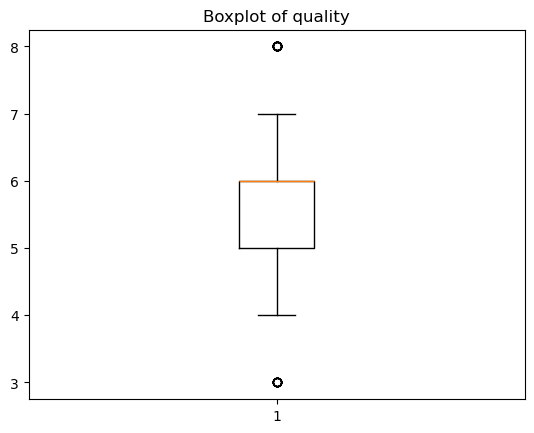

In [35]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [36]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
cols_to_transform = ['total sulfur dioxide', 'sulphates', 'chlorides', 'residual sugar', 'fixed acidity', 'volatile acidity', 'free sulfur dioxide',
'citric acid' ]
df[cols_to_transform] = pt.fit_transform(df[cols_to_transform])

C:\Users\Pratyasha\AppData\Local\Temp\ipykernel_12644\1183474808.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[cols_to_transform] = pt.fit_transform(df[cols_to_transform])


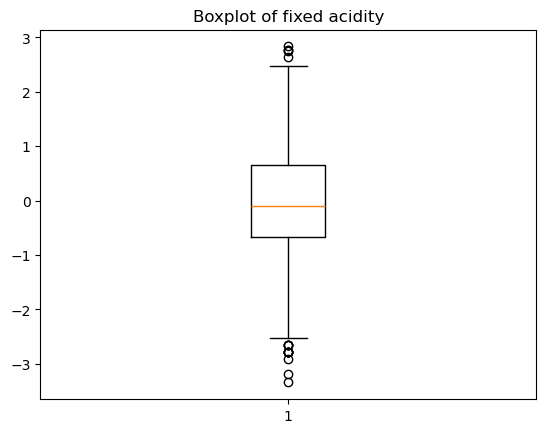

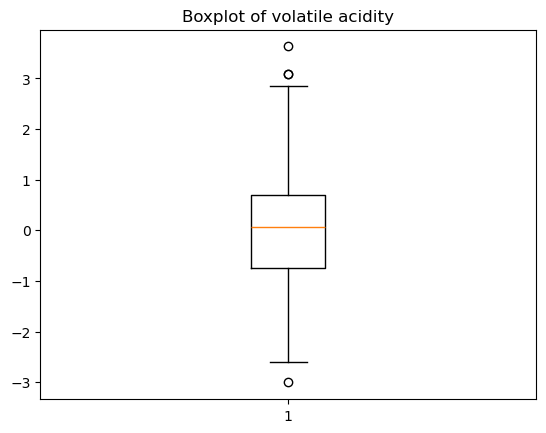

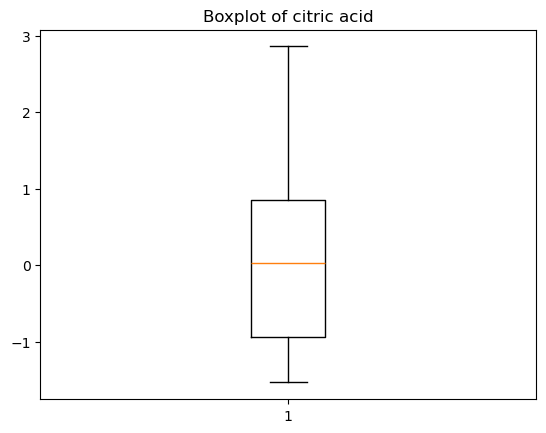

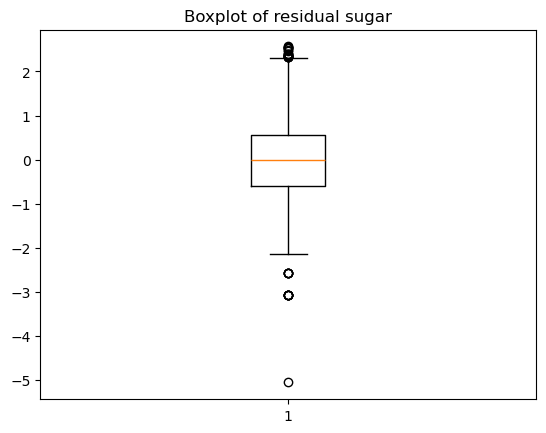

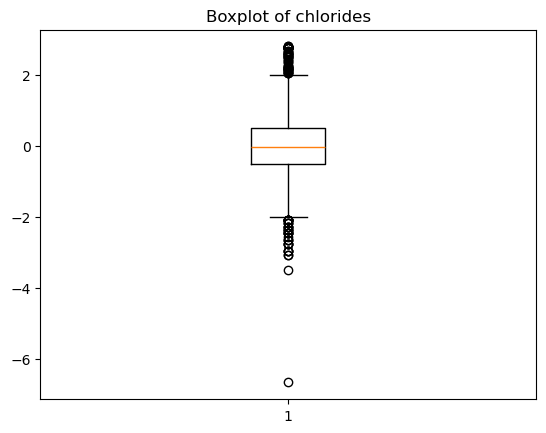

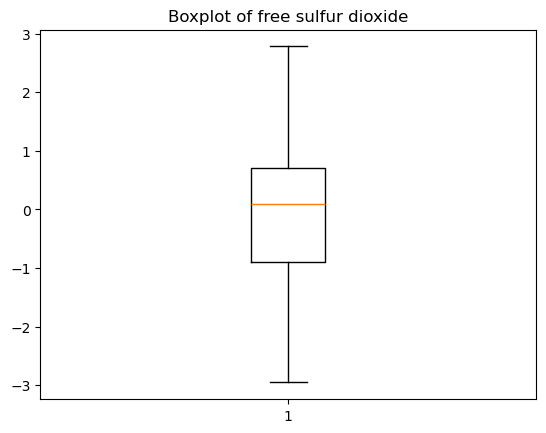

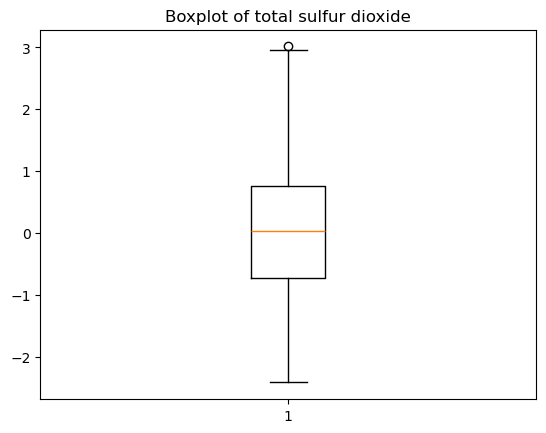

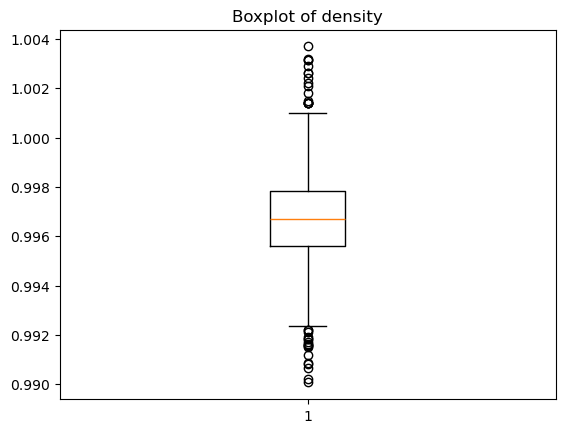

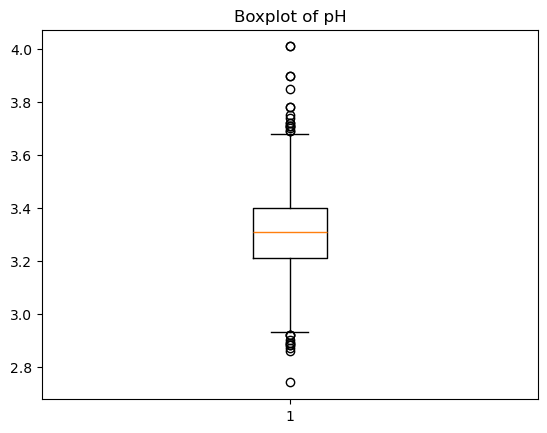

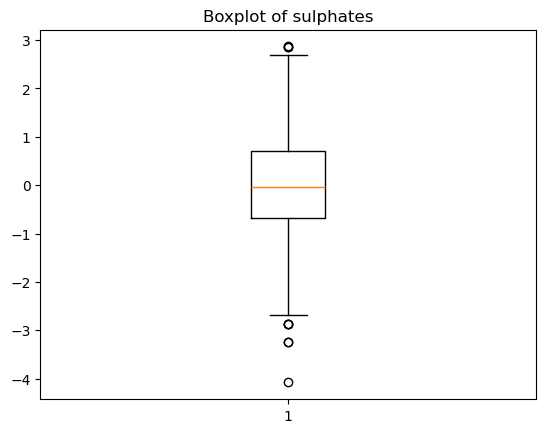

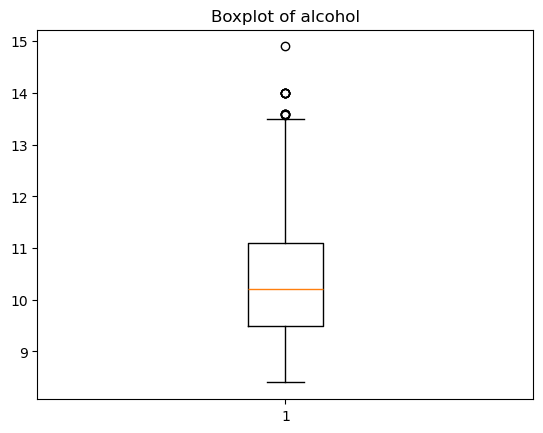

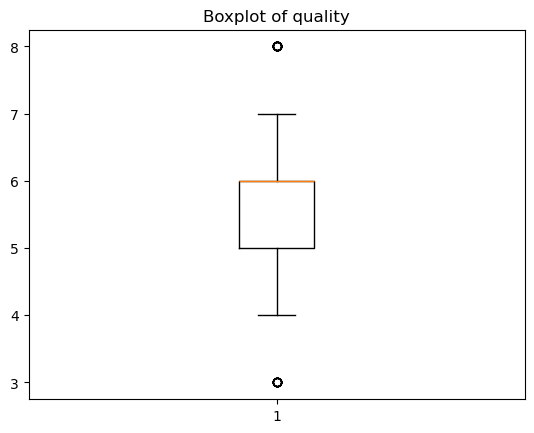

In [37]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [38]:
X = df.drop('quality', axis=1)
y = df['quality']

In [41]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use StandardScaler or RobustScaler on the whole set to ensure they all share the same range
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit model
model = LinearRegression()
model.fit(X_train_scaled, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
y_pred = model.predict(X_test_scaled)


mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Mean Squared Error (MSE): 0.4146
R-squared (R2) Score: 0.4147


C:\Users\Pratyasha\AppData\Local\Temp\ipykernel_12644\3747221855.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weight', y='Feature', data=importance_df, palette='coolwarm')


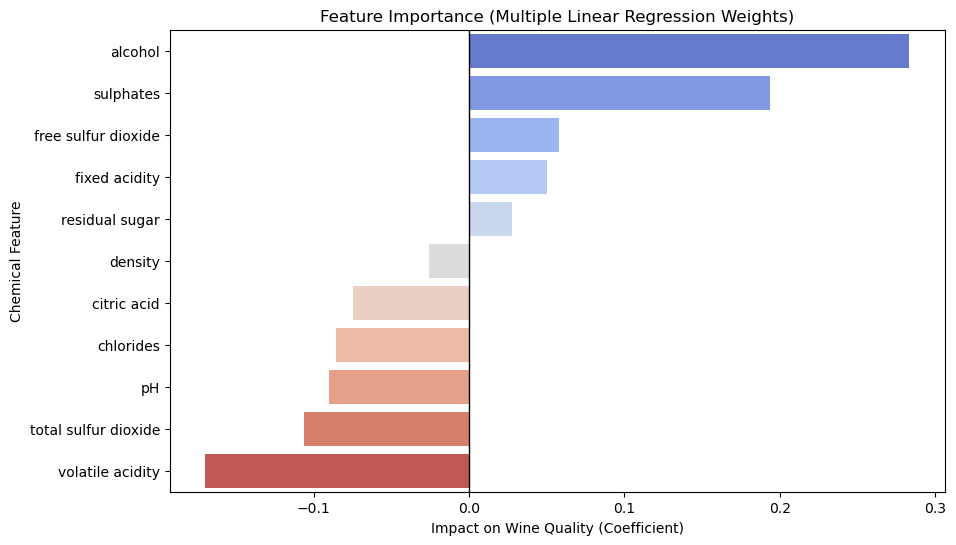

In [43]:
# 1. Create a DataFrame for the coefficients
# Ensure 'X' is defined as your features before the split
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_
})

# 2. Sort by weight for a better-looking plot
importance_df = importance_df.sort_values(by='Weight', ascending=False)

# 3. Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x='Weight', y='Feature', data=importance_df, palette='coolwarm')
plt.title('Feature Importance (Multiple Linear Regression Weights)')
plt.xlabel('Impact on Wine Quality (Coefficient)')
plt.ylabel('Chemical Feature')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Adds a line at 0
plt.show()

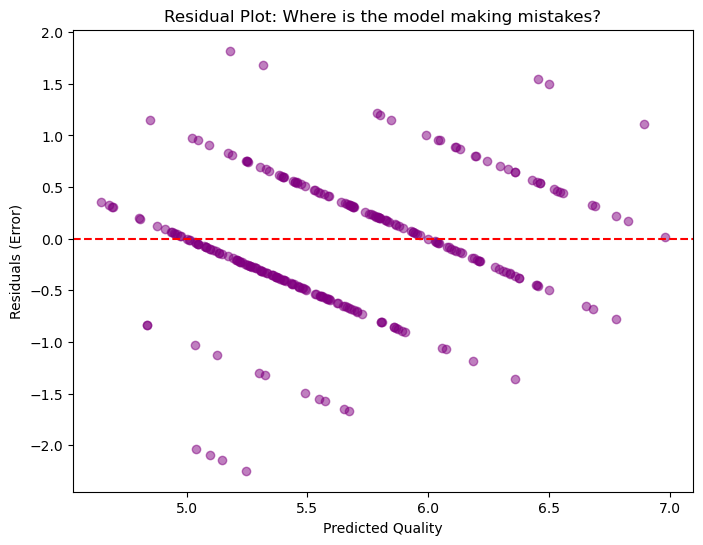

In [44]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Quality")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot: Where is the model making mistakes?")
plt.show()

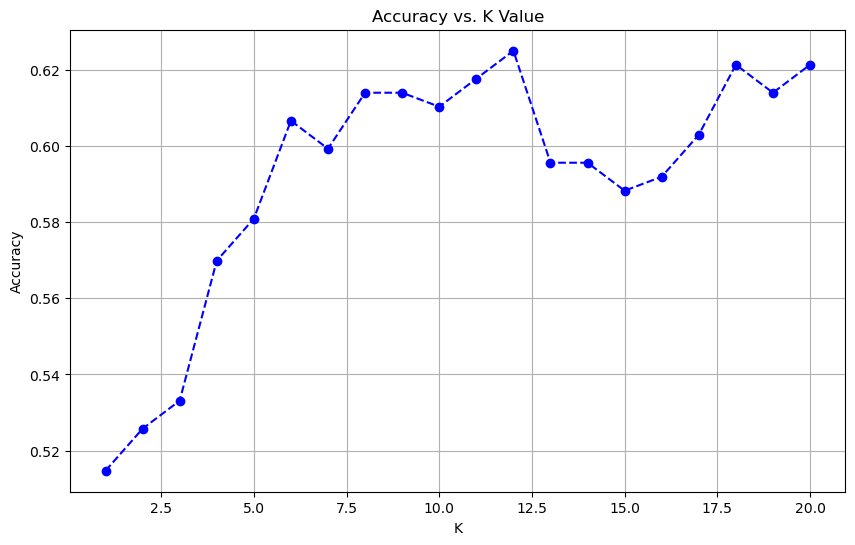

In [46]:
accuracy_rates = []
for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    accuracy_rates.append(accuracy_score(y_test, pred_i))

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), accuracy_rates, color='blue', linestyle='dashed', marker='o')
plt.title('Accuracy vs. K Value')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


In [47]:
best_k = 12
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
final_pred = final_knn.predict(X_test_scaled)
knn_r2 = r2_score(y_test, final_pred)

print(f"\n--- KNN Results (K={best_k}) ---")
print("Accuracy Score:", accuracy_score(y_test, final_pred))
print(f"R2 Score: {knn_r2:.4f}")
print("\nClassification Report:\n", classification_report(y_test, final_pred, zero_division=0))


--- KNN Results (K=12) ---
Accuracy Score: 0.625
R2 Score: 0.2993

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        11
           5       0.66      0.78      0.72       120
           6       0.58      0.59      0.58       103
           7       0.62      0.52      0.56        31
           8       0.00      0.00      0.00         3

    accuracy                           0.62       272
   macro avg       0.31      0.31      0.31       272
weighted avg       0.58      0.62      0.60       272

